<a href="https://colab.research.google.com/github/mdzikrim/MachineLearningClass/blob/main/Chapter_3_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import re
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier

np.random.seed(42)

In [2]:
# 1) Load MNIST (sesuai chapter: fetch_openml)
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X, y = mnist["data"], mnist["target"].astype(np.uint8)

# split seperti buku: 60k train, 10k test
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

X_train.shape, X_test.shape


((60000, 784), (10000, 784))

In [3]:
# 2) Grid search KNN (weights, n_neighbors)
knn = KNeighborsClassifier()

param_grid = {
    "weights": ["uniform", "distance"],
    "n_neighbors": [2, 3, 4, 5, 6, 7, 8],
}

grid = GridSearchCV(
    knn,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", test_acc)


Fitting 3 folds for each of 14 candidates, totalling 42 fits
Best params: {'n_neighbors': 4, 'weights': 'distance'}
Best CV accuracy: 0.9703500000000002
Test accuracy: 0.9714


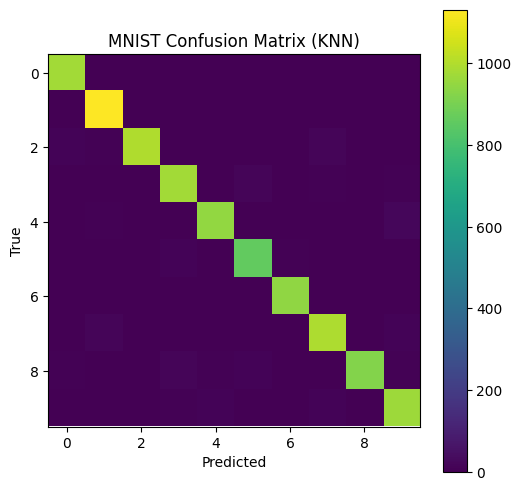

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.97      1.00      0.98      1135
           2       0.98      0.96      0.97      1032
           3       0.97      0.96      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.96      0.97      0.96       892
           6       0.98      0.99      0.98       958
           7       0.96      0.97      0.96      1028
           8       0.99      0.94      0.97       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [4]:
# 3) Confusion matrix (visual)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("MNIST Confusion Matrix (KNN)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

print(classification_report(y_test, y_pred))


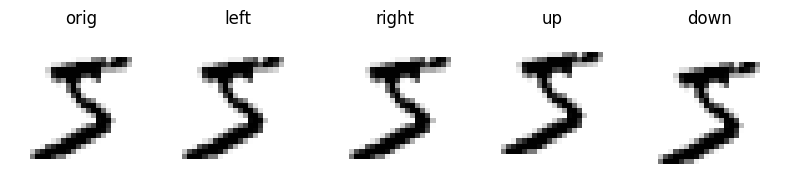

In [5]:
# 1) Shift helper (menggunakan scipy.ndimage.shift, seperti catatan kaki di buku)
from scipy.ndimage import shift as scipy_shift

def shift_image(image_784, dx, dy):
    """Shift 1 gambar MNIST (flattened 784) sebesar (dx,dy) pixel.
    dx: +1 ke kanan, -1 ke kiri
    dy: +1 ke bawah, -1 ke atas
    """
    image = image_784.reshape(28, 28)
    shifted = scipy_shift(image, shift=(dy, dx), cval=0)  # (row, col) = (dy, dx)
    return shifted.reshape(-1)

# sanity check: tampilkan contoh
idx = 0
img = X_train[idx]
imgs = [
    ("orig", img),
    ("left", shift_image(img, -1, 0)),
    ("right", shift_image(img, 1, 0)),
    ("up", shift_image(img, 0, -1)),
    ("down", shift_image(img, 0, 1)),
]

plt.figure(figsize=(8,2))
for i, (t, im) in enumerate(imgs):
    ax = plt.subplot(1, 5, i+1)
    plt.imshow(im.reshape(28,28), cmap="binary")
    plt.title(t)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [6]:
# 2) Data augmentation: tambah 4 shifted copies per image
X_train_aug = np.empty((len(X_train) * 5, 784), dtype=X_train.dtype)
y_train_aug = np.empty((len(y_train) * 5,), dtype=y_train.dtype)

X_train_aug[:len(X_train)] = X_train
y_train_aug[:len(y_train)] = y_train

shifts = [(-1,0),(1,0),(0,-1),(0,1)]
for i, (dx, dy) in enumerate(shifts, start=1):
    start = i * len(X_train)
    end = (i+1) * len(X_train)
    X_train_aug[start:end] = np.apply_along_axis(shift_image, 1, X_train, dx, dy)
    y_train_aug[start:end] = y_train

# Shuffle augmented set
shuffle_idx = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[shuffle_idx]
y_train_aug = y_train_aug[shuffle_idx]

X_train_aug.shape


(300000, 784)

In [7]:
# 3) Train the best KNN again on augmented data and evaluate
best_knn_aug = KNeighborsClassifier(**grid.best_params_)
best_knn_aug.fit(X_train_aug, y_train_aug)

y_pred_aug = best_knn_aug.predict(X_test)
test_acc_aug = accuracy_score(y_test, y_pred_aug)

print("Baseline test accuracy:", test_acc)
print("Augmented test accuracy:", test_acc_aug)


Baseline test accuracy: 0.9714
Augmented test accuracy: 0.9763
